# Covid-19 Analisys by Means of Big Data Processing Tools


### Salvatore Petrolo 224431.

In [1]:
import os

import numpy as np
import pandas as pd

from datetime import datetime


import matplotlib.pyplot as plt

In [2]:
%matplotlib inline
plt.set_cmap("Blues")

<Figure size 432x288 with 0 Axes>

In [3]:
__PROJECT_ROOT__ = "../"
__DATA_PATH__ = os.path.join(__PROJECT_ROOT__, "data")

__DATASET_NAME__ = "full_grouped.csv"
__DATASET_PATH__ = os.path.join(__DATA_PATH__, __DATASET_NAME__)

## Preliminaries

This notebook provides a description of the dataset used for this project.

It was taken from Kaggle, you can download it by clicking [here](https://www.kaggle.com/imdevskp/corona-virus-report?select=full_grouped.csv).



## About The Dataset   
The file contains the both cumulative and day-wise count of confirmed, death and recovered cases of COVID-19 from different countries from 22nd January 2020 to 27th July 2020.

## Data Inspection

In [4]:
dataframe = pd.read_csv(__DATASET_PATH__)

### Records Example


In [5]:
dataframe.head()

,Date,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,WHO Region
0,2020-01-22,Afghanistan,0,0,0,0,0,0,0,Eastern Mediterranean
1,2020-01-22,Albania,0,0,0,0,0,0,0,Europe
2,2020-01-22,Algeria,0,0,0,0,0,0,0,Africa
3,2020-01-22,Andorra,0,0,0,0,0,0,0,Europe
4,2020-01-22,Angola,0,0,0,0,0,0,0,Africa


In [6]:
countries = dataframe['Country/Region'].unique()
countries

array(['Afghanistan', 'Albania', 'Algeria', 'Andorra', 'Angola',
       'Antigua and Barbuda', 'Argentina', 'Armenia', 'Australia',
       'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh',
       'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin', 'Bhutan',
       'Bolivia', 'Bosnia and Herzegovina', 'Botswana', 'Brazil',
       'Brunei', 'Bulgaria', 'Burkina Faso', 'Burma', 'Burundi',
       'Cabo Verde', 'Cambodia', 'Cameroon', 'Canada',
       'Central African Republic', 'Chad', 'Chile', 'China', 'Colombia',
       'Comoros', 'Congo (Brazzaville)', 'Congo (Kinshasa)', 'Costa Rica',
       "Cote d'Ivoire", 'Croatia', 'Cuba', 'Cyprus', 'Czechia', 'Denmark',
       'Djibouti', 'Dominica', 'Dominican Republic', 'Ecuador', 'Egypt',
       'El Salvador', 'Equatorial Guinea', 'Eritrea', 'Estonia',
       'Eswatini', 'Ethiopia', 'Fiji', 'Finland', 'France', 'Gabon',
       'Gambia', 'Georgia', 'Germany', 'Ghana', 'Greece', 'Greenland',
       'Grenada', 'Guatemala', 'Guinea', 'G

In [7]:
countries.shape[0x0]

187

### Dataset Info

In [8]:
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35156 entries, 0 to 35155
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Date            35156 non-null  object
 1   Country/Region  35156 non-null  object
 2   Confirmed       35156 non-null  int64 
 3   Deaths          35156 non-null  int64 
 4   Recovered       35156 non-null  int64 
 5   Active          35156 non-null  int64 
 6   New cases       35156 non-null  int64 
 7   New deaths      35156 non-null  int64 
 8   New recovered   35156 non-null  int64 
 9   WHO Region      35156 non-null  object
dtypes: int64(7), object(3)
memory usage: 2.7+ MB


### Attributes Description

#### Date
Date of the report.

#### County/Region
Country of origin.

#### Confirmed
Cumulative number of confirmed cases till this day.

#### Deaths
Cumulative number of deaths till this day

### Recovered
Cumulative number of recovered cases till this day.

#### Active
Active cases till this day.

#### New cases
New cases in this day.

#### New deaths
New deaths in this day.

#### New recovered
New recovered in this day.

#### WHO Region
World Health Organization region.

### Dataset Stats

In [9]:
dataframe.describe()

,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered
count,3.515600e+04,35156.000000,3.515600e+04,3.515600e+04,35156.00000,35156.000000,35156.000000
mean,2.356663e+04,1234.068239,1.104813e+04,1.128443e+04,469.36375,18.603339,269.315593
std,1.499818e+05,7437.238354,6.454640e+04,8.997149e+04,3005.86754,115.706351,2068.063852
min,0.000000e+00,0.000000,0.000000e+00,-2.000000e+00,0.00000,-1918.000000,-16298.000000
25%,1.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.00000,0.000000,0.000000
50%,2.500000e+02,4.000000,3.300000e+01,8.500000e+01,2.00000,0.000000,0.000000
75%,3.640250e+03,78.250000,1.286250e+03,1.454000e+03,75.00000,1.000000,20.000000
max,4.290259e+06,148011.000000,1.846641e+06,2.816444e+06,77255.00000,3887.000000,140050.000000


### Dataset Assert
The dataset is provided as pre-processed.
However, before proceeding, let's ensure that this pre-processed data is temporarily sorted.

In [10]:
for i in range(0x1, len(dataframe)):
    date_prev = datetime.strptime(dataframe.Date[i - 0x1], '%Y-%m-%d').date()
    date_cur =  datetime.strptime(dataframe.Date[i], '%Y-%m-%d').date()

    assert date_prev <= date_cur

That's fine.

### Attribute Selection
Some attributes are not relevant for the analysis and for this reason they will be discarded.

In particular, we will discard **WHO Region** since this analysis is focused on country-wise cases.

In [11]:
dataframe.drop(columns=['WHO Region'], inplace=True)

In [12]:
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35156 entries, 0 to 35155
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Date            35156 non-null  object
 1   Country/Region  35156 non-null  object
 2   Confirmed       35156 non-null  int64 
 3   Deaths          35156 non-null  int64 
 4   Recovered       35156 non-null  int64 
 5   Active          35156 non-null  int64 
 6   New cases       35156 non-null  int64 
 7   New deaths      35156 non-null  int64 
 8   New recovered   35156 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 2.4+ MB


### Attributes Standardization
#### Attributes' Names

In [13]:
columns = [name.lower().replace(' ', '_') for name in dataframe.columns]
columns[0x1] = columns[0x1][: columns[0x1].index('/')]
renaming_dict = {old : new for new, old in zip(columns, dataframe.columns)}
renaming_dict

{'Date': 'date',
 'Country/Region': 'country',
 'Confirmed': 'confirmed',
 'Deaths': 'deaths',
 'Recovered': 'recovered',
 'Active': 'active',
 'New cases': 'new_cases',
 'New deaths': 'new_deaths',
 'New recovered': 'new_recovered'}

In [14]:
dataframe.rename(columns=renaming_dict, inplace=True)

#### Attributes' Values

In [15]:
dataframe.country = dataframe.country.str.lower()

In [16]:
dataframe

,date,country,confirmed,deaths,recovered,active,new_cases,new_deaths,new_recovered
0,2020-01-22,afghanistan,0,0,0,0,0,0,0
1,2020-01-22,albania,0,0,0,0,0,0,0
2,2020-01-22,algeria,0,0,0,0,0,0,0
3,2020-01-22,andorra,0,0,0,0,0,0,0
4,2020-01-22,angola,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...
35151,2020-07-27,west bank and gaza,10621,78,3752,6791,152,2,0
35152,2020-07-27,western sahara,10,1,8,1,0,0,0
35153,2020-07-27,yemen,1691,483,833,375,10,4,36
35154,2020-07-27,zambia,4552,140,2815,1597,71,1,465


### Dumping New Dataset

In [17]:
dataframe.to_csv(os.path.join(__DATA_PATH__, "covid19_full_filtered.csv"), index=False)

In [18]:
filtered_dataframe = pd.read_csv(os.path.join(__DATA_PATH__, "covid19_full_filtered.csv"))

In [19]:
filtered_dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35156 entries, 0 to 35155
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   date           35156 non-null  object
 1   country        35156 non-null  object
 2   confirmed      35156 non-null  int64 
 3   deaths         35156 non-null  int64 
 4   recovered      35156 non-null  int64 
 5   active         35156 non-null  int64 
 6   new_cases      35156 non-null  int64 
 7   new_deaths     35156 non-null  int64 
 8   new_recovered  35156 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 2.4+ MB


## Visual Inspection

### Records x Country

In [20]:
data = dataframe.country.value_counts()

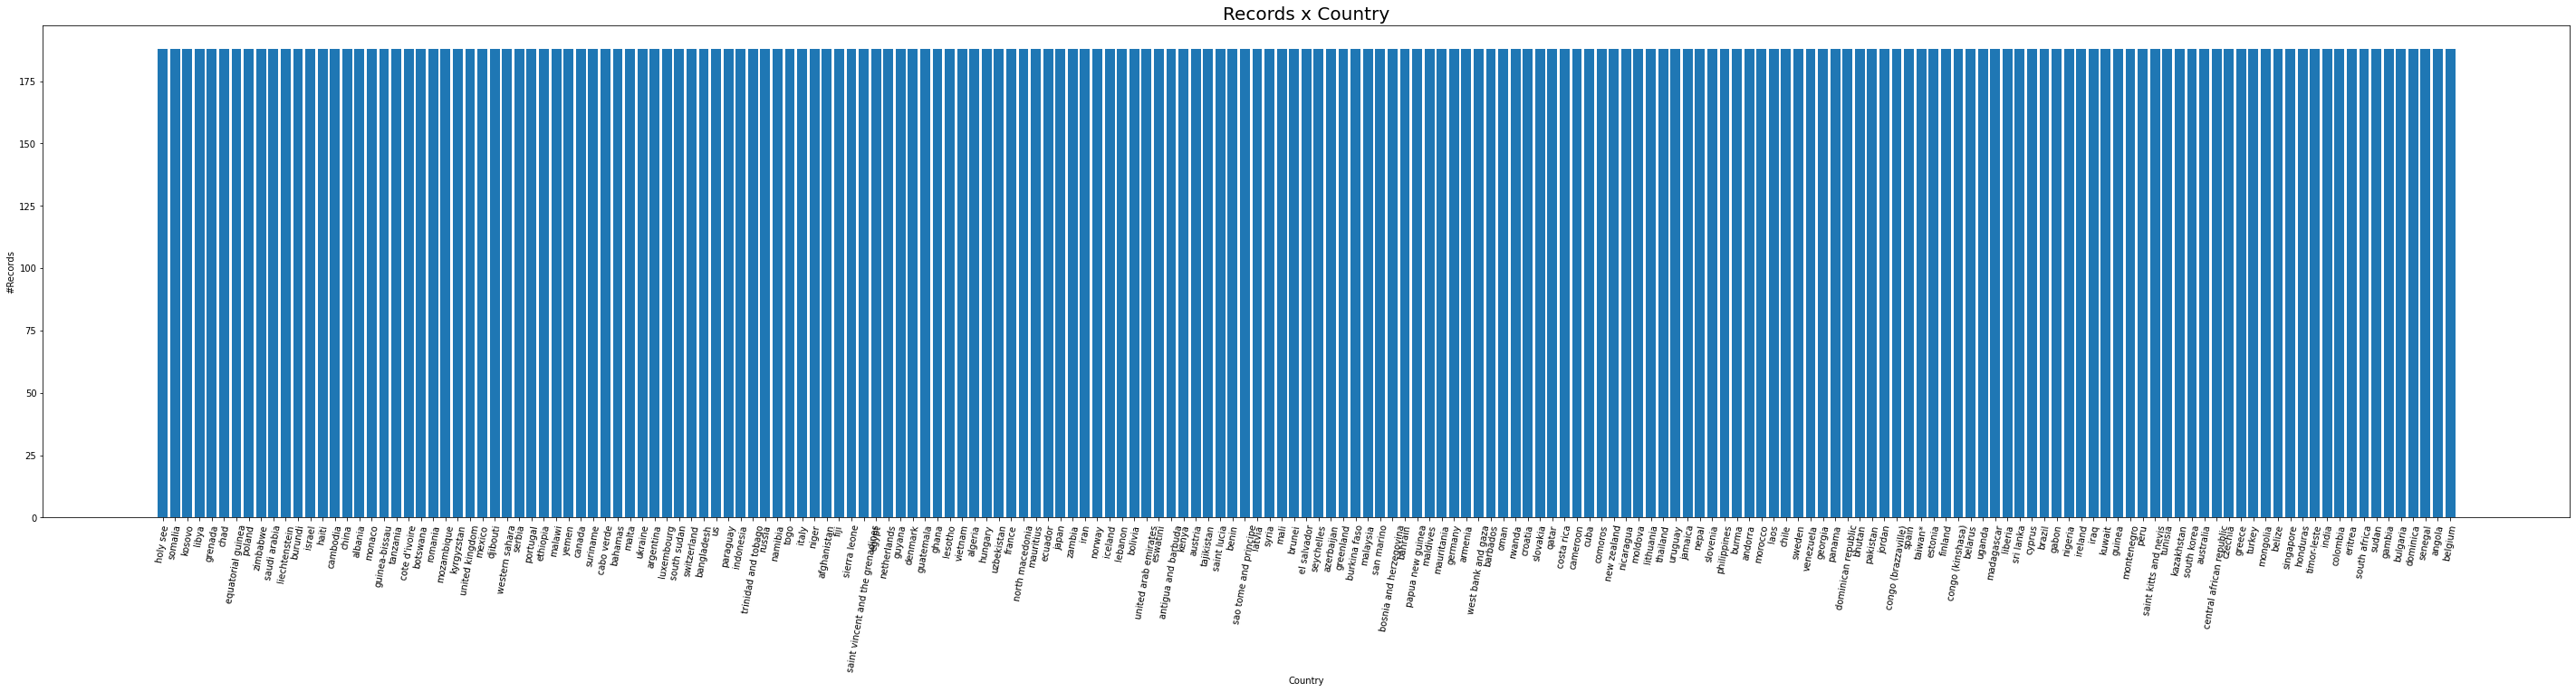

In [21]:
plt.figure(figsize=(0x32, 0xa))
plt.bar(x=data.index, height=data)
plt.ylabel("#Records")
plt.xlabel("Country")
plt.title("Records x Country", size=0x14)
plt.xticks(rotation=0x50)
plt.show()

In [22]:
np.unique(data)

array([188])

### Max New Deaths x Country

In [23]:
data = dict()
for i in range(len(dataframe)):
    record = dataframe.iloc[i]
    value = data.get(record.country, 0x0)
    data[record.country] = max(value, record.new_deaths)

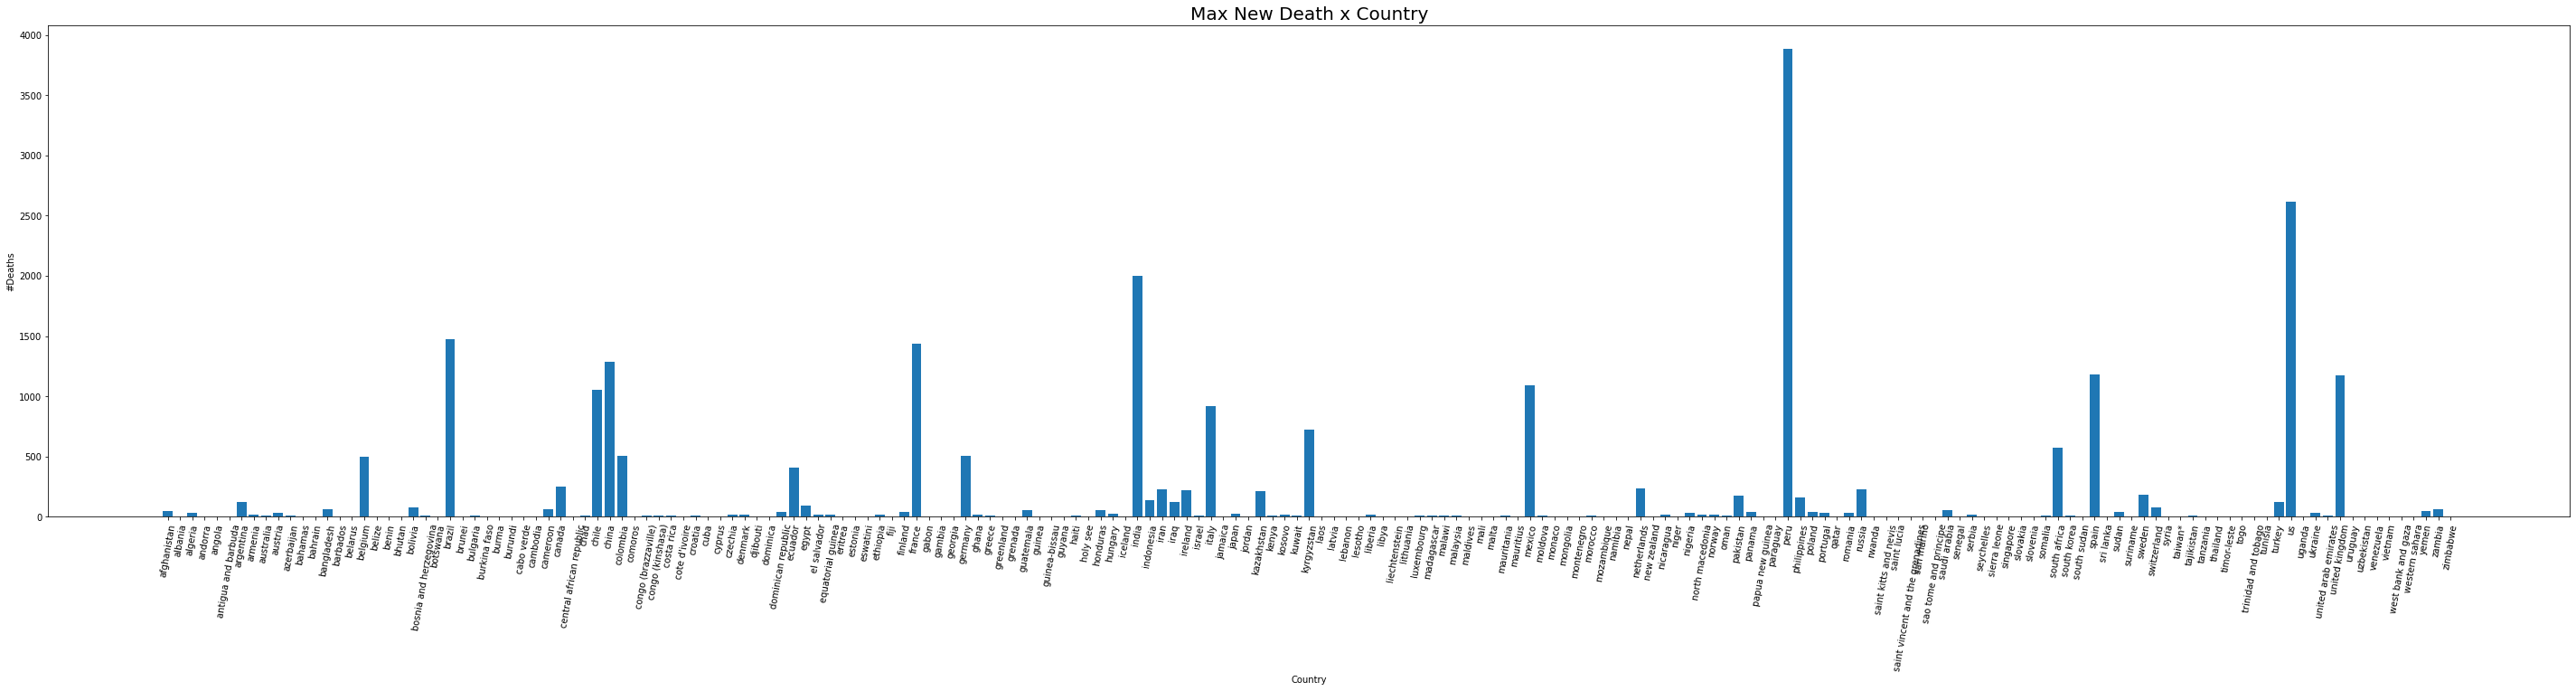

In [24]:
plt.figure(figsize=(0x32, 0xa))
plt.bar(x=data.keys(), height=data.values())
plt.ylabel("#Deaths")
plt.xlabel("Country")
plt.title("Max New Death x Country", size=0x14)
plt.xticks(rotation=0x50)
plt.show()

### Total Confirmed Cases x Country

In [25]:
last_day_date = dataframe.iloc[len(dataframe) - 0x1].date
data = {row.country: row.confirmed for _, row in dataframe[dataframe.date == last_day_date][['country', 'confirmed']].iterrows()}

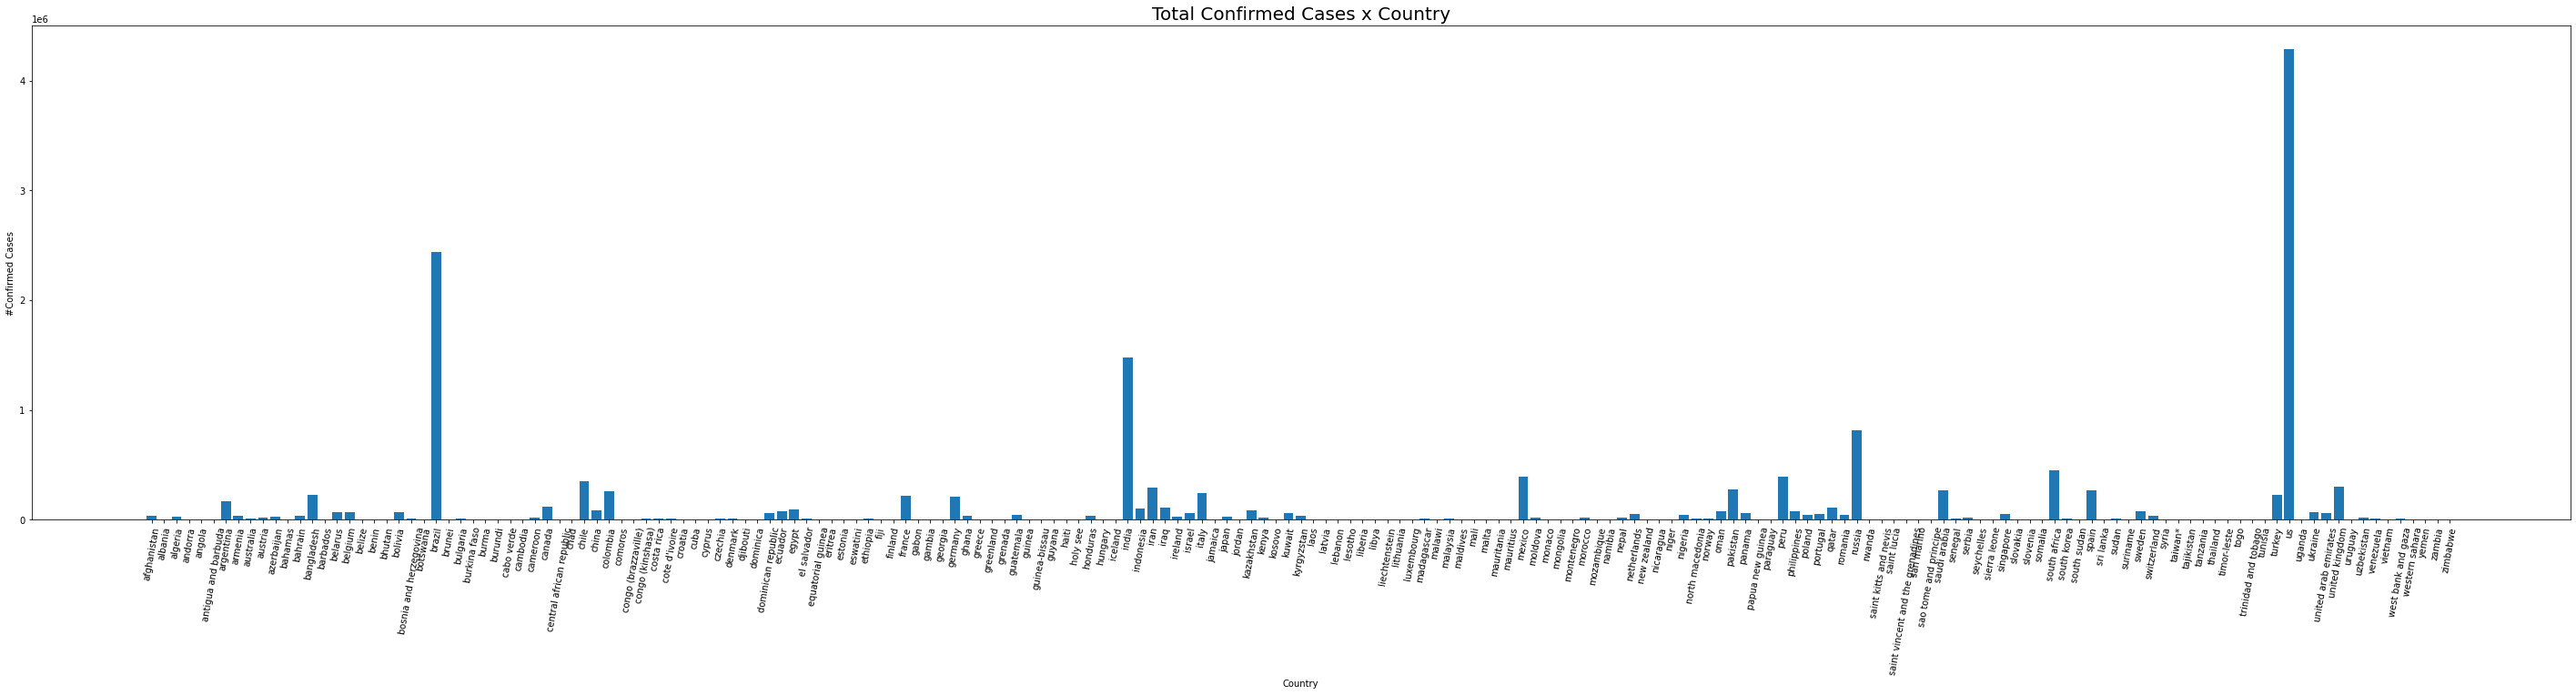

In [26]:
plt.figure(figsize=(0x32, 0xa))
plt.bar(x=data.keys(), height=data.values())
plt.ylabel("#Confirmed Cases")
plt.xlabel("Country")
plt.title("Total Confirmed Cases x Country", size=0x14)
plt.xticks(rotation=0x50)
plt.show()